# Week 3.1 — Jacobi, Gauss-Seidel, and SOR on the 1D Poisson System
Same three stationary iterative methods as Week 1, now applied to the discretized 1D Poisson operator instead of the dense SOAR correlation matrix — a case where, unlike Week 1, the matrix *is* diagonally dominant, so all three methods converge.

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.linalg import solve_triangular
import matplotlib.pyplot as plt

## Problem setup
Builds the standard tridiagonal 1D Poisson matrix $A = \text{tridiag}(-1,2,-1)/h^2$ (finite-difference discretization of $-u''$ with Dirichlet boundary conditions) and a constant right-hand side $b=\mathbf{1}$.

In [2]:
n = 20
h = 1 / (n + 1)
A_sparse = (1 / h**2) * sp.diags([-1, 2, -1], [-1, 0, 1], shape=(n, n))
A = A_sparse.toarray()
b = np.ones(n)

# Iteration parameters
maxit = 200
tol = 1e-8
x0 = np.zeros(n)
norm_b = np.linalg.norm(b)

## Jacobi
Splits $A=D-L-U$ and iterates $x^{k+1}=D^{-1}(L+U)x^k+D^{-1}b$. Because $A$ is (weakly) diagonally dominant here, the Jacobi iteration matrix has spectral radius below 1 and the method converges — unlike the dense SOAR matrix in Week 1.

In [3]:
D = np.diag(np.diag(A))
L = -np.tril(A, -1)
U = -np.triu(A, 1)
invD = np.linalg.inv(D)
GJ = invD @ (L + U)
cJ = invD @ b
x = x0.copy()
resJ = [np.linalg.norm(b - A @ x0) / norm_b]
for k in range(maxit):
    x = GJ @ x + cJ
    res = np.linalg.norm(b - A @ x) / norm_b
    resJ.append(res)
    if res < tol:
        break

## Gauss-Seidel
Solves $(D-L)x^{k+1}=Ux^k+b$ by forward substitution, reusing already-updated components within the same sweep — typically about twice as fast as Jacobi for this kind of tridiagonal system.

In [4]:
M_gs = D - L
x = x0.copy()
resGS = [np.linalg.norm(b - A @ x0) / norm_b]
for k in range(maxit):
    # Solve M*x_new = U*x + b using forward substitution
    x = solve_triangular(M_gs, U @ x + b, lower=True)
    res = np.linalg.norm(b - A @ x) / norm_b
    resGS.append(res)
    if res < tol:
        break

## SOR
Extrapolates the Gauss-Seidel update with the theoretically optimal relaxation factor $\omega = 2/(1+\sin(\pi/(n+1)))$ for this discretized Laplacian, which gives a marked speed-up in convergence rate over plain Gauss-Seidel.

In [5]:
omega = 2 / (1 + np.sin(np.pi / (n + 1)))  # optimal parameter
M_sor = (1/omega) * D - L
N_sor = (1 - omega)/omega * D + U
x = x0.copy()
resSOR = [np.linalg.norm(b - A @ x0) / norm_b]
for k in range(maxit):
    # Solve M_sor*x_new = N_sor*x + b using forward substitution
    x = solve_triangular(M_sor, N_sor @ x + b, lower=True)
    res = np.linalg.norm(b - A @ x) / norm_b
    resSOR.append(res)
    if res < tol:
        break

## Compare convergence
Plots the relative residual norm on a log scale for all three methods, showing the expected ordering Jacobi (slowest) < Gauss-Seidel < SOR (fastest).

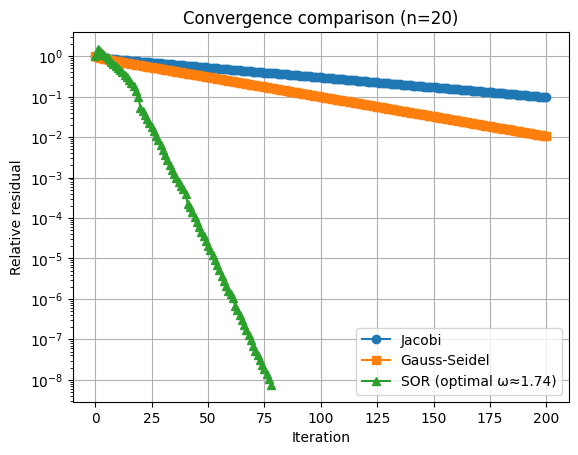

In [6]:
plt.figure()
plt.semilogy(resJ, '-o', label='Jacobi')
plt.semilogy(resGS, '-s', label='Gauss-Seidel')
plt.semilogy(resSOR, '-^', label=f'SOR (optimal ω≈{omega:.2f})')
plt.xlabel('Iteration')
plt.ylabel('Relative residual')
plt.legend()
plt.grid(True)
plt.title(f'Convergence comparison (n={n})')
plt.show()